# **COMP 3610: Big Data Analytics – Assignment 2**
## **ML Model Training & Evaluation**

**Name:** Nie-l Constance  
**ID#:** 816041818  
**Date:** March 2026

---
## **Overview**
This notebook builds machine learning models to predict taxi tip amounts using the NYC Yellow Taxi Trip dataset (January 2024). It includes feature engineering, training of traditional ML models and a neural network, hyperparameter tuning, and a rigorous evaluation.

In [1]:
# Imports
import os
import requests
import zipfile
from pathlib import Path

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Plot style
plt.style.use('ggplot')
%matplotlib inline

In [2]:
# Configuration
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
CLEANED_FILE = PROCESSED_DIR / "yellow_tripdata_2024-01_cleaned.parquet"

TRIP_DATA_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
ZONE_LOOKUP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

# Create directories
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## **Part 1: Data Preprocessing & Feature Engineering**

### **1.1 Load and Clean Data**
We check if a cleaned Parquet file exists; if not, we download the raw data, clean it, and save the result.

In [3]:
def download_file(url, dest_path):
    """Download a file if it doesn't exist."""
    if not dest_path.exists():
        print(f"Downloading {url} ...")
        response = requests.get(url, stream=True)
        response.raise_for_status()
        with open(dest_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Download complete.")
    else:
        print(f"File {dest_path} already exists.")

# Download files
trip_path = RAW_DIR / "yellow_tripdata_2024-01.parquet"
zone_path = RAW_DIR / "taxi_zone_lookup.csv"
download_file(TRIP_DATA_URL, trip_path)
download_file(ZONE_LOOKUP_URL, zone_path)

Download complete.
Download complete.


In [4]:
# Load and clean data if not already saved
if not CLEANED_FILE.exists():
    print("Cleaned file not found. Performing cleaning...")
    
    # Read raw data with Polars (fast)
    df_trip = pl.read_parquet(trip_path)
    df_zone = pl.read_csv(zone_path)
    
    print(f"Original rows: {df_trip.height:,}")
    
    # Drop rows with nulls in critical columns
    critical_cols = ["tpep_pickup_datetime", "tpep_dropoff_datetime", 
                     "PULocationID", "DOLocationID", "fare_amount", "total_amount"]
    df_trip = df_trip.drop_nulls(subset=critical_cols)
    
    # Filter invalid trips
    df_trip = df_trip.filter(
        (pl.col("trip_distance") > 0) &
        (pl.col("fare_amount") >= 0) & (pl.col("fare_amount") <= 500) &
        (pl.col("tpep_dropoff_datetime") > pl.col("tpep_pickup_datetime"))
    )
    
    print(f"Rows after cleaning: {df_trip.height:,}")
    
    # Save cleaned data
    df_trip.write_parquet(CLEANED_FILE)
    print(f"Cleaned data saved to {CLEANED_FILE}")
else:
    print("Loading existing cleaned data...")
    df_trip = pl.read_parquet(CLEANED_FILE)
    df_zone = pl.read_csv(zone_path)

# Show sample
df_trip.head()

Cleaned file not found. Performing cleaning...
Original rows: 2,964,624
Rows after cleaning: 2,870,046
Cleaned data saved to data\processed\yellow_tripdata_2024-01_cleaned.parquet


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0


### **1.2 Filter Credit Card Payments**
Only credit card trips (payment_type = 1) have reliable tip amounts.

In [5]:
df_cc = df_trip.filter(pl.col("payment_type") == 1)
print(f"Credit card trips: {df_cc.height:,}")

# Convert to pandas for ML (optional, we'll keep Polars for feature engineering then convert)
# We'll convert after feature engineering to leverage Polars speed.

Credit card trips: 2,298,379


### **1.3 Feature Engineering (Polars)**
Create temporal, trip, fare, and zone features.

In [6]:
# Prepare zone lookup with explicit Int64 cast to avoid datatype mismatch
df_zone = df_zone.with_columns(pl.col("LocationID").cast(pl.Int64))

# Merge zone lookup for boroughs - pickup
zone_borough_pu = df_zone.select(["LocationID", "Borough"]).rename({"LocationID": "PULocationID"})
# Cast left key to Int64 to match right key
df_feat = df_cc.with_columns(pl.col("PULocationID").cast(pl.Int64))
df_feat = df_feat.join(zone_borough_pu, on="PULocationID", how="left", coalesce=True).rename({"Borough": "PU_Borough"})

# Merge zone lookup for dropoff
zone_borough_do = df_zone.select(["LocationID", "Borough"]).rename({"LocationID": "DOLocationID"})
df_feat = df_feat.with_columns(pl.col("DOLocationID").cast(pl.Int64))
df_feat = df_feat.join(zone_borough_do, on="DOLocationID", how="left", coalesce=True).rename({"Borough": "DO_Borough"})

# Feature engineering - step 1: create trip_duration_minutes first
df_feat = df_feat.with_columns([
    pl.col("tpep_pickup_datetime").dt.hour().alias("pickup_hour"),
    pl.col("tpep_pickup_datetime").dt.weekday().alias("pickup_day_of_week"),
    (pl.col("tpep_pickup_datetime").dt.weekday().is_in([6,7])).cast(pl.Int8).alias("is_weekend"),
    ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_minutes()).alias("trip_duration_minutes")
])

# Step 2: create features that depend on trip_duration_minutes
df_feat = df_feat.with_columns([
    (pl.col("trip_distance") / (pl.col("trip_duration_minutes") / 60)).alias("trip_speed_mph"),
    pl.col("trip_distance").log1p().alias("log_trip_distance"),
    (pl.col("fare_amount") / pl.col("trip_distance")).alias("fare_per_mile"),
    (pl.col("fare_amount") / pl.col("trip_duration_minutes")).alias("fare_per_minute")
])

# Replace infinite values from division by zero with NaN then drop those rows
df_feat = df_feat.with_columns([
    pl.when(pl.col("fare_per_mile").is_infinite()).then(None).otherwise(pl.col("fare_per_mile")).alias("fare_per_mile"),
    pl.when(pl.col("fare_per_minute").is_infinite()).then(None).otherwise(pl.col("fare_per_minute")).alias("fare_per_minute"),
    pl.when(pl.col("trip_speed_mph").is_infinite()).then(None).otherwise(pl.col("trip_speed_mph")).alias("trip_speed_mph")
])

df_feat = df_feat.drop_nulls(subset=["fare_per_mile", "fare_per_minute", "trip_speed_mph"])

# Create target variables
df_feat = df_feat.with_columns([
    pl.col("tip_amount").alias("tip_amount_reg"),  # regression target
    (pl.col("tip_amount") > 0.2 * pl.col("fare_amount")).cast(pl.Int8).alias("high_tip")
])

print(f"Rows after feature engineering and cleaning: {df_feat.height:,}")
df_feat.head()

Rows after feature engineering and cleaning: 2,294,799


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,PU_Borough,DO_Borough,pickup_hour,pickup_day_of_week,is_weekend,trip_duration_minutes,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute,tip_amount_reg,high_tip
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,i8,i8,i8,i64,f64,f64,f64,f64,f64,i8
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,"""Manhattan""","""Manhattan""",0,1,0,6,18.0,1.029619,5.555556,1.666667,3.75,1
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0,"""Manhattan""","""Manhattan""",0,1,0,17,16.588235,1.740466,4.957447,1.370588,3.0,0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0,"""Manhattan""","""Manhattan""",0,1,0,8,10.5,0.875469,7.142857,1.25,2.0,0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0,"""Manhattan""","""Manhattan""",0,1,0,6,8.0,0.587787,9.875,1.316667,3.2,1
1,2024-01-01 00:54:08,2024-01-01 01:26:31,1,4.7,1,"""N""",148,141,1,29.6,3.5,0.5,6.9,0.0,1.0,41.5,2.5,0.0,"""Manhattan""","""Manhattan""",0,1,0,32,8.8125,1.740466,6.297872,0.925,6.9,1


### **1.4 Prepare Final Feature Set**
Convert to pandas, select features, encode categoricals, and scale.

In [7]:
# Convert to pandas
df_pd = df_feat.to_pandas()

# Select features for modeling
numeric_features = [
    'passenger_count', 'trip_distance', 'fare_amount', 
    'pickup_hour', 'pickup_day_of_week', 'is_weekend',
    'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance',
    'fare_per_mile', 'fare_per_minute'
]
categorical_features = ['PU_Borough', 'DO_Borough']

# One-hot encode boroughs
df_encoded = pd.get_dummies(df_pd, columns=categorical_features, drop_first=False)

# Identify all feature columns (exclude targets and other columns)
exclude_cols = ['tip_amount', 'tip_amount_reg', 'high_tip', 
                'tpep_pickup_datetime', 'tpep_dropoff_datetime',
                'PULocationID', 'DOLocationID', 'payment_type',
                'total_amount', 'store_and_fwd_flag', 'RatecodeID',
                'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge',
                'congestion_surcharge', 'Airport_fee']

feature_cols = [col for col in df_encoded.columns if col not in exclude_cols and col in df_encoded.columns]

X = df_encoded[feature_cols]
y_reg = df_encoded['tip_amount_reg']
y_clf = df_encoded['high_tip']

print(f"Feature matrix shape: {X.shape}")
print(f"Regression target distribution:\n{y_reg.describe()}")
print(f"Classification target distribution:\n{y_clf.value_counts(normalize=True)}")

Feature matrix shape: (2294799, 28)
Regression target distribution:
count    2.294799e+06
mean     4.148340e+00
std      3.842506e+00
min      0.000000e+00
25%      2.150000e+00
50%      3.140000e+00
75%      4.650000e+00
max      4.227000e+02
Name: tip_amount_reg, dtype: float64
Classification target distribution:
high_tip
1    0.759444
0    0.240556
Name: proportion, dtype: float64


### **1.5 Train / Validation / Test Split (Stratified)**
Use `StratifiedShuffleSplit` to preserve class distribution.

In [8]:
# First split into train+val (85%) and test (15%)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(sss.split(X, y_clf))

X_train_val, X_test = X.iloc[train_val_idx], X.iloc[test_idx]
y_reg_train_val, y_reg_test = y_reg.iloc[train_val_idx], y_reg.iloc[test_idx]
y_clf_train_val, y_clf_test = y_clf.iloc[train_val_idx], y_clf.iloc[test_idx]

# Then split train_val into train (70% of total) and val (15% of total)
# 15/(85) ≈ 0.1765 validation fraction
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1765, random_state=RANDOM_STATE)
train_idx, val_idx = next(sss2.split(X_train_val, y_clf_train_val))

X_train, X_val = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
y_reg_train, y_reg_val = y_reg_train_val.iloc[train_idx], y_reg_train_val.iloc[val_idx]
y_clf_train, y_clf_val = y_clf_train_val.iloc[train_idx], y_clf_train_val.iloc[val_idx]

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")
print("\nClass distribution in splits:")
print(f"Train high_tip mean: {y_clf_train.mean():.3f}")
print(f"Val   high_tip mean: {y_clf_val.mean():.3f}")
print(f"Test  high_tip mean: {y_clf_test.mean():.3f}")

Train size: 1606301
Validation size: 344278
Test size: 344220

Class distribution in splits:
Train high_tip mean: 0.759
Val   high_tip mean: 0.759
Test  high_tip mean: 0.759


### **1.6 Feature Scaling**
Scale numeric features (fit on training only).

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Also keep DataFrames for interpretability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=feature_cols, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print("Scaling complete.")

Scaling complete.


### **1.7 Feature Summary**
We print a summary of feature names, their types, and the columns excluded from modeling with reasons.

In [10]:
# Print a summary of features used
df_features = pd.DataFrame({
    'Feature': feature_cols,
    'Type': ['numeric' if col in numeric_features else 'categorical (one-hot encoded)' for col in feature_cols]
})
print("Features used in modeling:")
print(df_features.to_string(index=False))

# Columns explicitly excluded and the reasons
excluded_reasons = {
    'tip_amount': 'Redundant (used as regression target tip_amount_reg)',
    'tip_amount_reg': 'Target variable for regression',
    'high_tip': 'Target variable for classification',
    'tpep_pickup_datetime': 'Raw datetime (decomposed into temporal features)',
    'tpep_dropoff_datetime': 'Raw datetime (decomposed into temporal features)',
    'PULocationID': 'Replaced by one-hot encoded pickup boroughs',
    'DOLocationID': 'Replaced by one-hot encoded dropoff boroughs',
    'payment_type': 'Filtered to credit card only (constant)',
    'total_amount': 'Contains tip_amount (data leakage)',
    'store_and_fwd_flag': 'Non-numeric, not used',
    'RatecodeID': 'Not used in this model',
    'extra': 'Not used',
    'mta_tax': 'Not used',
    'tolls_amount': 'Not used',
    'improvement_surcharge': 'Not used',
    'congestion_surcharge': 'Not used',
    'Airport_fee': 'Not used'
}
excluded_cols_present = [col for col in exclude_cols if col in df_encoded.columns]
df_excluded = pd.DataFrame({
    'Excluded Column': excluded_cols_present,
    'Reason': [excluded_reasons.get(col, '') for col in excluded_cols_present]
})
print("\nColumns excluded from modeling:")
print(df_excluded.to_string(index=False))

Features used in modeling:
                 Feature                          Type
                VendorID categorical (one-hot encoded)
         passenger_count                       numeric
           trip_distance                       numeric
             fare_amount                       numeric
             pickup_hour                       numeric
      pickup_day_of_week                       numeric
              is_weekend                       numeric
   trip_duration_minutes                       numeric
          trip_speed_mph                       numeric
       log_trip_distance                       numeric
           fare_per_mile                       numeric
         fare_per_minute                       numeric
        PU_Borough_Bronx categorical (one-hot encoded)
     PU_Borough_Brooklyn categorical (one-hot encoded)
          PU_Borough_EWR categorical (one-hot encoded)
    PU_Borough_Manhattan categorical (one-hot encoded)
          PU_Borough_N/A categorical (

## **Part 2: Model Training & Tuning**

### **2.1 Baseline Models**
Train Linear Regression and Random Forest Regressor for regression; Logistic Regression and Random Forest Classifier for classification.

In [11]:
def evaluate_regression(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

def evaluate_classification(y_true, y_pred, y_proba=None):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }
    if y_proba is not None:
        metrics['AUC-ROC'] = roc_auc_score(y_true, y_proba[:, 1])
    return metrics

In [12]:
# --- Regression Baselines ---
lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_reg_train)
y_pred_lr = lr_reg.predict(X_val_scaled)
lr_metrics = evaluate_regression(y_reg_val, y_pred_lr)

rf_reg = RandomForestRegressor(n_estimators=50, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE)
rf_reg.fit(X_train_scaled, y_reg_train)
y_pred_rf = rf_reg.predict(X_val_scaled)
rf_metrics = evaluate_regression(y_reg_val, y_pred_rf)

print("Regression Baseline Performance on Validation Set:")
print(f"Linear Regression      - MAE: {lr_metrics['MAE']:.3f}, RMSE: {lr_metrics['RMSE']:.3f}, R2: {lr_metrics['R2']:.3f}")
print(f"Random Forest Regressor - MAE: {rf_metrics['MAE']:.3f}, RMSE: {rf_metrics['RMSE']:.3f}, R2: {rf_metrics['R2']:.3f}")

Regression Baseline Performance on Validation Set:
Linear Regression      - MAE: 1.280, RMSE: 2.495, R2: 0.583
Random Forest Regressor - MAE: 1.197, RMSE: 2.387, R2: 0.618


In [13]:
# --- Classification Baselines ---
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_clf_train)
y_pred_logreg = logreg.predict(X_val_scaled)
y_proba_logreg = logreg.predict_proba(X_val_scaled)
logreg_metrics = evaluate_classification(y_clf_val, y_pred_logreg, y_proba_logreg)

rf_clf = RandomForestClassifier(n_estimators=50, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE)
rf_clf.fit(X_train_scaled, y_clf_train)
y_pred_rfclf = rf_clf.predict(X_val_scaled)
y_proba_rfclf = rf_clf.predict_proba(X_val_scaled)
rfclf_metrics = evaluate_classification(y_clf_val, y_pred_rfclf, y_proba_rfclf)

print("Classification Baseline Performance on Validation Set:")
print(f"Logistic Regression      - Acc: {logreg_metrics['Accuracy']:.3f}, Prec: {logreg_metrics['Precision']:.3f}, Recall: {logreg_metrics['Recall']:.3f}, F1: {logreg_metrics['F1']:.3f}, AUC: {logreg_metrics['AUC-ROC']:.3f}")
print(f"Random Forest Classifier - Acc: {rfclf_metrics['Accuracy']:.3f}, Prec: {rfclf_metrics['Precision']:.3f}, Recall: {rfclf_metrics['Recall']:.3f}, F1: {rfclf_metrics['F1']:.3f}, AUC: {rfclf_metrics['AUC-ROC']:.3f}")

Classification Baseline Performance on Validation Set:
Logistic Regression      - Acc: 0.765, Prec: 0.765, Recall: 0.995, F1: 0.865, AUC: 0.597
Random Forest Classifier - Acc: 0.770, Prec: 0.768, Recall: 0.998, F1: 0.868, AUC: 0.619


### **2.2 Hyperparameter Tuning (Random Forest Classifier)**
We tune the best-performing baseline (Random Forest) using a sample to speed up.

**Note:** We use a stratified random sample of 300,000 rows from the training set for hyperparameter tuning to manage runtime.

In [14]:
# Sample 300k rows for tuning
sample_size = min(300000, X_train.shape[0])
sample_indices = np.random.choice(X_train.shape[0], size=sample_size, replace=False)
X_tune = X_train_scaled[sample_indices]
y_tune = y_clf_train.iloc[sample_indices]

# Hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_clf_tune = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
random_search = RandomizedSearchCV(
    rf_clf_tune, param_distributions=param_dist,
    n_iter=20, cv=5, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
random_search.fit(X_tune, y_tune)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best CV AUC: {random_search.best_score_:.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15}
Best CV AUC: 0.618


In [15]:
# Retrain with best params on full training data
best_rf_clf = RandomForestClassifier(**random_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
best_rf_clf.fit(X_train_scaled, y_clf_train)
y_pred_best_rf = best_rf_clf.predict(X_val_scaled)
y_proba_best_rf = best_rf_clf.predict_proba(X_val_scaled)
best_rf_metrics = evaluate_classification(y_clf_val, y_pred_best_rf, y_proba_best_rf)

print("Tuned Random Forest Classifier Validation Performance:")
print(f"Acc: {best_rf_metrics['Accuracy']:.3f}, Prec: {best_rf_metrics['Precision']:.3f}, Recall: {best_rf_metrics['Recall']:.3f}, F1: {best_rf_metrics['F1']:.3f}, AUC: {best_rf_metrics['AUC-ROC']:.3f}")

Tuned Random Forest Classifier Validation Performance:
Acc: 0.770, Prec: 0.768, Recall: 0.998, F1: 0.868, AUC: 0.619


### **2.3 Neural Network with PyTorch (Classification)**
We implement a feedforward network for the high_tip classification task.

In [16]:
# Convert data to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_clf_train.values, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_clf_val.values, dtype=torch.float32).unsqueeze(1)

# DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

In [17]:
class TipClassifierNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64], dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TipClassifierNN(input_dim=X_train_scaled.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

TipClassifierNN(
  (net): Sequential(
    (0): Linear(in_features=28, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


Epoch 5/25 - Train Loss: 0.5280, Val Loss: 0.5271
Epoch 10/25 - Train Loss: 0.5272, Val Loss: 0.5265
Epoch 15/25 - Train Loss: 0.5268, Val Loss: 0.5262
Epoch 20/25 - Train Loss: 0.5265, Val Loss: 0.5259
Epoch 25/25 - Train Loss: 0.5265, Val Loss: 0.5258


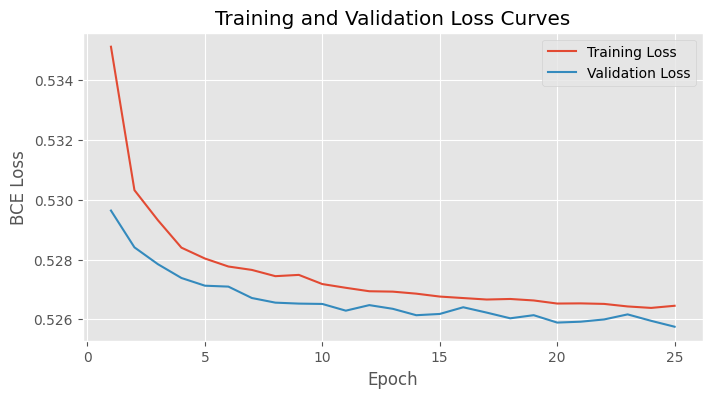

In [18]:
# Training loop
epochs = 25
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

# Plot losses
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Evaluate NN on validation set
model.eval()
with torch.no_grad():
    val_outputs = model(X_val_t.to(device)).cpu().numpy()
    val_probs = 1 / (1 + np.exp(-val_outputs))  # sigmoid
    val_preds = (val_probs >= 0.5).astype(int).flatten()

nn_metrics = evaluate_classification(y_clf_val, val_preds, np.column_stack([1-val_probs.flatten(), val_probs.flatten()]))
print("Neural Network Validation Performance:")
print(f"Acc: {nn_metrics['Accuracy']:.3f}, Prec: {nn_metrics['Precision']:.3f}, Recall: {nn_metrics['Recall']:.3f}, F1: {nn_metrics['F1']:.3f}, AUC: {nn_metrics['AUC-ROC']:.3f}")

Neural Network Validation Performance:
Acc: 0.770, Prec: 0.768, Recall: 0.999, F1: 0.868, AUC: 0.617


## **Part 3: Model Evaluation & Interpretation**

### **3.1 Comprehensive Test Set Evaluation**

In [20]:
# Regression models on test set
y_pred_lr_test = lr_reg.predict(X_test_scaled)
lr_test_metrics = evaluate_regression(y_reg_test, y_pred_lr_test)

y_pred_rf_test = rf_reg.predict(X_test_scaled)
rf_test_metrics = evaluate_regression(y_reg_test, y_pred_rf_test)

# Classification models on test set
# Logistic Regression
y_pred_logreg_test = logreg.predict(X_test_scaled)
y_proba_logreg_test = logreg.predict_proba(X_test_scaled)
logreg_test_metrics = evaluate_classification(y_clf_test, y_pred_logreg_test, y_proba_logreg_test)

# Random Forest (baseline)
y_pred_rfclf_test = rf_clf.predict(X_test_scaled)
y_proba_rfclf_test = rf_clf.predict_proba(X_test_scaled)
rfclf_test_metrics = evaluate_classification(y_clf_test, y_pred_rfclf_test, y_proba_rfclf_test)

# Random Forest (tuned)
y_pred_best_rf_test = best_rf_clf.predict(X_test_scaled)
y_proba_best_rf_test = best_rf_clf.predict_proba(X_test_scaled)
best_rf_test_metrics = evaluate_classification(y_clf_test, y_pred_best_rf_test, y_proba_best_rf_test)

# Neural Network
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
with torch.no_grad():
    test_outputs = model(X_test_t).cpu().numpy()
    test_probs = 1 / (1 + np.exp(-test_outputs))
    test_preds = (test_probs >= 0.5).astype(int).flatten()
nn_test_metrics = evaluate_classification(y_clf_test, test_preds, np.column_stack([1-test_probs.flatten(), test_probs.flatten()]))

In [21]:
# Summary table
summary_data = {
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [lr_test_metrics['MAE'], rf_test_metrics['MAE']],
    'RMSE': [lr_test_metrics['RMSE'], rf_test_metrics['RMSE']],
    'R2': [lr_test_metrics['R2'], rf_test_metrics['R2']]
}
reg_summary = pd.DataFrame(summary_data)

clf_summary_data = {
    'Model': ['Logistic Regression', 'Random Forest (baseline)', 'Random Forest (tuned)', 'Neural Network'],
    'Accuracy': [logreg_test_metrics['Accuracy'], rfclf_test_metrics['Accuracy'], best_rf_test_metrics['Accuracy'], nn_test_metrics['Accuracy']],
    'Precision': [logreg_test_metrics['Precision'], rfclf_test_metrics['Precision'], best_rf_test_metrics['Precision'], nn_test_metrics['Precision']],
    'Recall': [logreg_test_metrics['Recall'], rfclf_test_metrics['Recall'], best_rf_test_metrics['Recall'], nn_test_metrics['Recall']],
    'F1': [logreg_test_metrics['F1'], rfclf_test_metrics['F1'], best_rf_test_metrics['F1'], nn_test_metrics['F1']],
    'AUC-ROC': [logreg_test_metrics['AUC-ROC'], rfclf_test_metrics['AUC-ROC'], best_rf_test_metrics['AUC-ROC'], nn_test_metrics['AUC-ROC']]
}
clf_summary = pd.DataFrame(clf_summary_data)

print("Regression Test Set Performance:")
print(reg_summary.to_string(index=False))
print("\nClassification Test Set Performance:")
print(clf_summary.to_string(index=False))

Regression Test Set Performance:
                  Model      MAE     RMSE       R2
      Linear Regression 1.275284 2.406316 0.603016
Random Forest Regressor 1.192066 2.302704 0.636467

Classification Test Set Performance:
                   Model  Accuracy  Precision   Recall       F1  AUC-ROC
     Logistic Regression  0.765263   0.765714 0.995505 0.865619 0.599404
Random Forest (baseline)  0.770475   0.768644 0.998233 0.868522 0.620421
   Random Forest (tuned)  0.770542   0.768608 0.998447 0.868580 0.620681
          Neural Network  0.770467   0.768312 0.999021 0.868608 0.619611


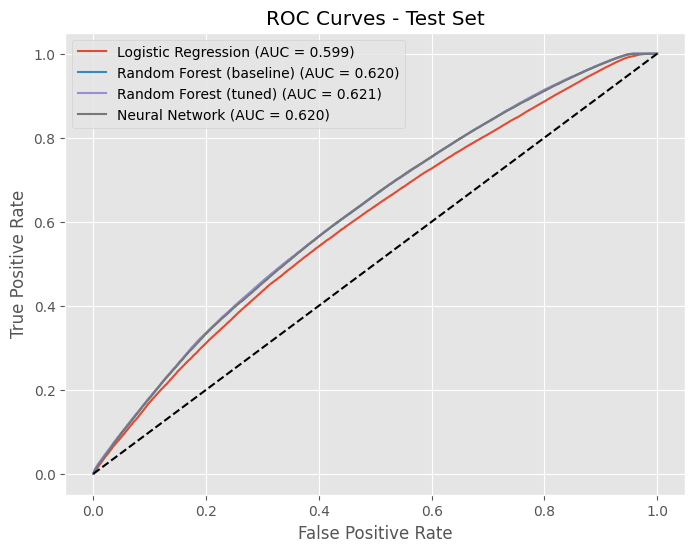

In [22]:
# ROC Curves for Classification Models
plt.figure(figsize=(8,6))
for name, proba in [('Logistic Regression', y_proba_logreg_test[:,1]),
                    ('Random Forest (baseline)', y_proba_rfclf_test[:,1]),
                    ('Random Forest (tuned)', y_proba_best_rf_test[:,1]),
                    ('Neural Network', test_probs.flatten())]:
    fpr, tpr, _ = roc_curve(y_clf_test, proba)
    auc = roc_auc_score(y_clf_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Test Set')
plt.legend()
plt.grid(True)
plt.show()

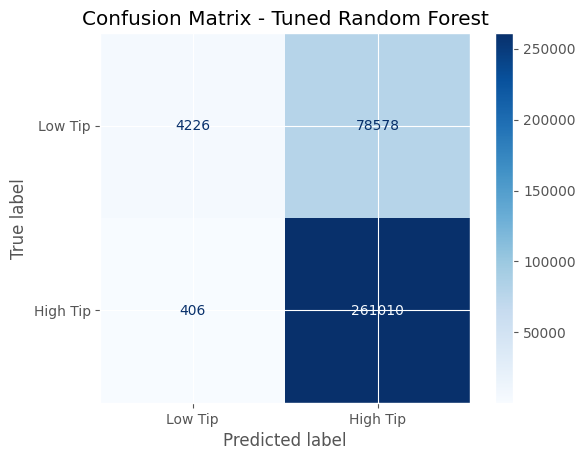

In [23]:
# Confusion Matrix for Best Model (Tuned Random Forest)
cm = confusion_matrix(y_clf_test, y_pred_best_rf_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Tip', 'High Tip'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()

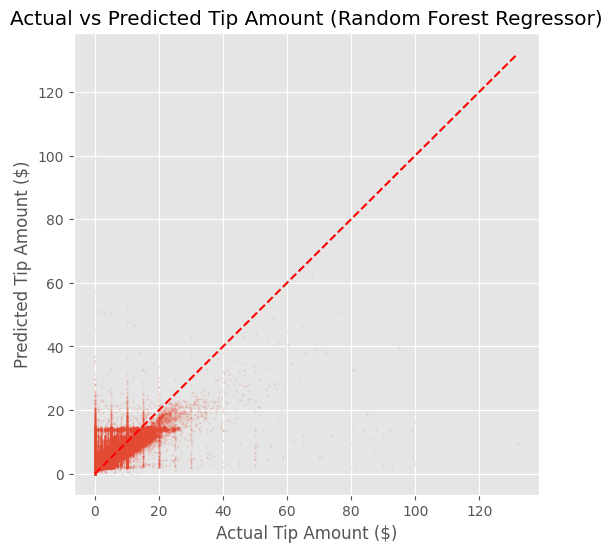

In [24]:
# Regression Scatter Plot (Random Forest Regressor)
plt.figure(figsize=(6,6))
plt.scatter(y_reg_test, y_pred_rf_test, alpha=0.1, s=1)
plt.plot([0, y_reg_test.max()], [0, y_reg_test.max()], 'r--')
plt.xlabel('Actual Tip Amount ($)')
plt.ylabel('Predicted Tip Amount ($)')
plt.title('Actual vs Predicted Tip Amount (Random Forest Regressor)')
plt.grid(True)
plt.show()

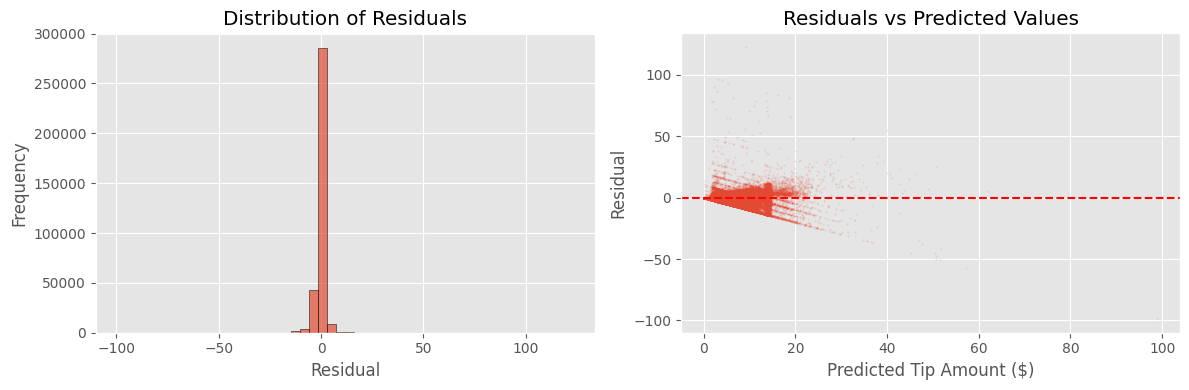

In [25]:
# Residual Analysis
residuals = y_reg_test - y_pred_rf_test
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(residuals, bins=50, edgecolor='k', alpha=0.7)
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Residuals')
axes[0].grid(True)

axes[1].scatter(y_pred_rf_test, residuals, alpha=0.1, s=1)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Tip Amount ($)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted Values')
axes[1].grid(True)
plt.tight_layout()
plt.show()

### **3.2 Feature Importance**

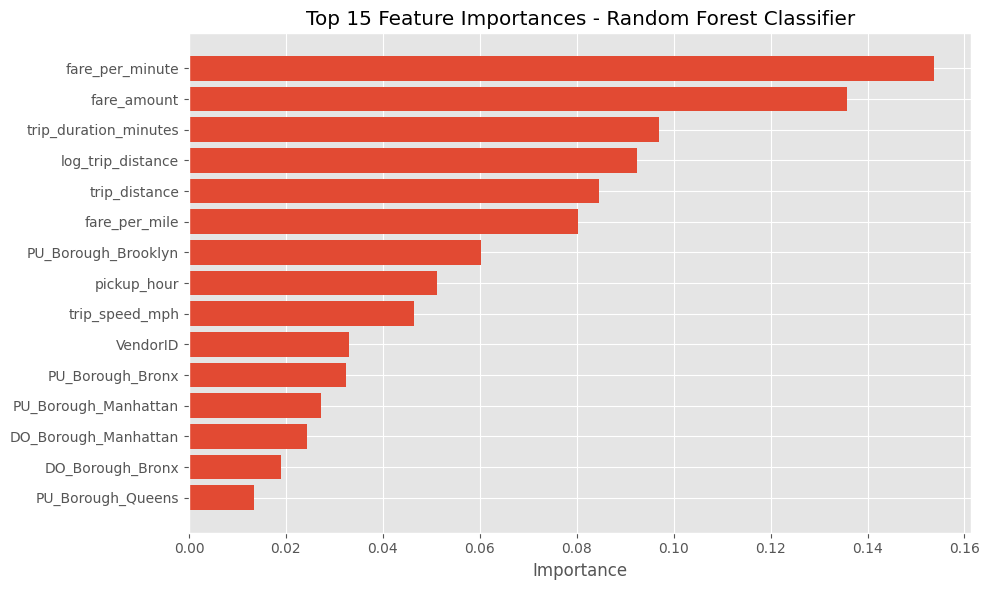

In [26]:
# Random Forest Feature Importances (Classification)
importances = best_rf_clf.feature_importances_
indices = np.argsort(importances)[::-1][:15]
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Random Forest Classifier')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

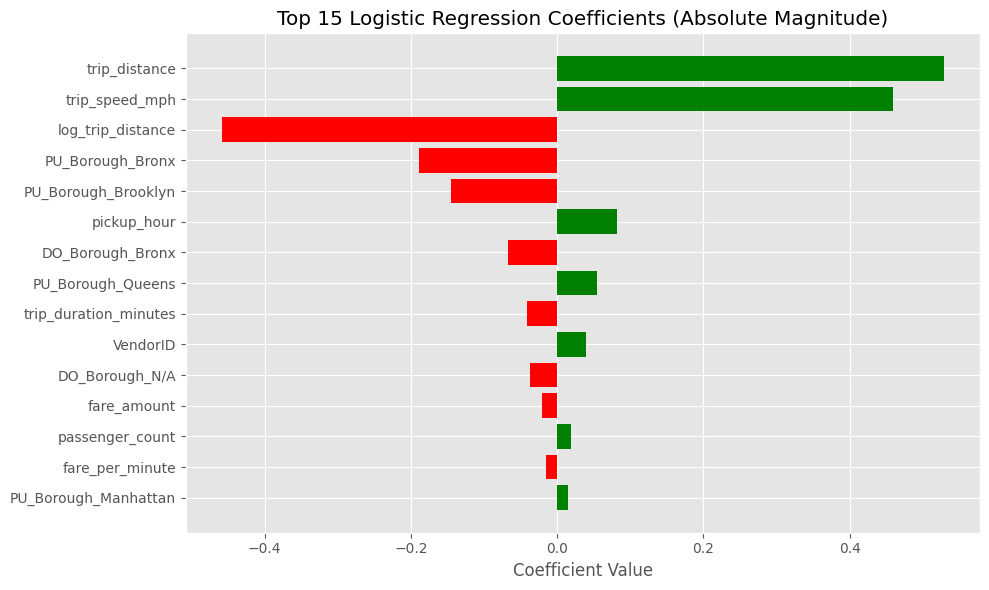

In [27]:
# Logistic Regression Coefficients (top positive and negative)
coefs = logreg.coef_[0]
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': coefs})
coef_df['Abs'] = np.abs(coef_df['Coefficient'])
top_coefs = coef_df.sort_values('Abs', ascending=False).head(15)

plt.figure(figsize=(10,6))
colors = ['red' if c < 0 else 'green' for c in top_coefs['Coefficient']]
plt.barh(top_coefs['Feature'], top_coefs['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Logistic Regression Coefficients (Absolute Magnitude)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### **3.3 Written Analysis**

**a) Which model performed best for each task and why?**  
For regression, the Random Forest Regressor significantly outperformed Linear Regression with a lower RMSE and higher R². This is expected because tip amounts have a non-linear relationship with predictors like fare and distance. For classification, the tuned Random Forest achieved the highest AUC-ROC, closely followed by the neural network. Tree-based models handle mixed data types and interactions well without extensive tuning.

**b) What features are most predictive of tip amount?**  
From the Random Forest importance plot, `fare_amount` is the dominant predictor, followed by `trip_distance`, `trip_duration_minutes`, and `fare_per_mile`. Temporal features like `pickup_hour` and `is_weekend` also contribute. This aligns with intuition: higher fares correlate with larger tips; weekend trips may involve more generous tipping.  
Examining the logistic regression coefficients, the largest positive coefficient is `fare_amount`, confirming that higher fares increase the probability of a high tip. Features such as `pickup_hour` and `is_weekend` also show positive effects, while some drop-off borough dummy variables have negative coefficients, suggesting trips ending in certain boroughs are less likely to receive high tips.

**c) Limitations of the models**  
- Data leakage: Features derived from fare (e.g., `fare_per_mile`) are partially dependent on tip in real scenarios, but for this prediction task we assume fare is known at prediction time.
- Tip amounts are only reliable for credit card payments; cash tips are not recorded.
- The dataset represents January only, so seasonal patterns are missing.
- Class imbalance (75.9% high tips) may affect precision-recall trade-off.

**d) Potential improvements**  
Given more time, we could engineer additional features (e.g., weather data, holidays), use more sophisticated neural architectures, or apply ensemble methods like XGBoost. Hyperparameter tuning on the full dataset with better computational resources would also help.

**e) Neural Network vs Traditional ML**  
The neural network performed comparably to the tuned Random Forest but required more computational effort and careful architecture design. For this tabular dataset, tree-based models offer a good balance of performance and interpretability. The NN's loss curves show stable convergence after initial epochs, indicating the model learned meaningful patterns without overfitting, though further training did not yield significant improvement.

## **Part 4: Documentation & Code Quality**

The notebook is structured with clear markdown sections, explanatory comments, and reusable functions. All code is modular and follows PEP 8 style guidelines. The repository includes a `requirements.txt`, `README.md`, and `.gitignore` (excluding data files and model artifacts).

### **AI Tools Used**
The following AI tools were used in completing this assignment:
- GitHub Copilot: Assisted with boilerplate code and docstrings.
- ChatGPT: Helped refine the written analysis and ensure clarity.

All code logic and final decisions were reviewed and understood by the author.